In [1]:
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, f1_score, recall_score, precision_score,
    precision_recall_curve, average_precision_score
)
import xgboost as xgb
import lightgbm as lgb
import shap
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import platform
SEED = 42
np.random.seed(SEED)
print("✅ 모델링 라이브러리 로드 완료")

✅ 모델링 라이브러리 로드 완료


In [2]:
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# ── 파생변수 추가 버전
type1_df = pd.read_csv('../../data/df_type1_파생변수추가.csv')
type1_df['Pressure_Diff_ratio'] = type1_df['Casting_Pressure'] / type1_df['Cylinder_Pressure']

NEW_DERIVED = [
    'clamp_per_press', 'temp_diff',
    'press_time_ratio', 'spray_cycle_ratio', 'heat_index'    
]

FEATURES = [
    'Velocity_1', 'Velocity_2', 'Velocity_3', 'High_Velocity',
    'Rapid_Rise_Time', 'Biscuit_Thickness', 'Clamping_Force', 'Cycle_Time',
    'Pressure_Rise_Time', 'Casting_Pressure', 'Cylinder_Pressure',
    'Spray_Time', 'Spray_1_Time', 'Spray_2_Time',
    'Melting_Furnace_Temp', 'Air_Pressure', 'Coolant_Temp', 'Coolant_Pressure',
    'Factory_Temp', 'Factory_Humidity',
    'Pressure_Diff_ratio',
    # 신규 파생변수
    'clamp_per_press', 'temp_diff',
    'press_time_ratio', 'spray_cycle_ratio', 'heat_index'   
]

X = type1_df[FEATURES].copy()
y = type1_df['Defect_Status'].copy()

print(f"피처 수: {len(FEATURES)}개 (원본 21 + 신규 파생변수 {len(NEW_DERIVED)}개)")
print(f"타겟 분포 → 양품: {(y==0).sum()} / 불량: {(y==1).sum()} ({y.mean()*100:.1f}%)")

피처 수: 26개 (원본 21 + 신규 파생변수 5개)
타겟 분포 → 양품: 2075 / 불량: 576 (21.7%)


## STEP 1. 피처 및 타겟 정의

## STEP 2. Train/Test Split

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED)

pos_weight = (y_train==0).sum() / (y_train==1).sum()

print(f"훈련셋: {X_train.shape[0]}행  |  테스트셋: {X_test.shape[0]}행")
print(f"훈련셋 불량률: {y_train.mean()*100:.1f}%  |  테스트셋 불량률: {y_test.mean()*100:.1f}%")
print(f"scale_pos_weight: {pos_weight:.2f}")

훈련셋: 2120행  |  테스트셋: 531행
훈련셋 불량률: 21.7%  |  테스트셋 불량률: 21.7%
scale_pos_weight: 3.60


In [4]:
from sklearn.ensemble import IsolationForest

# 수치형 컬럼만 선택
X_train_num = X_train.select_dtypes(include=['int64', 'float64'])
X_test_num = X_test.select_dtypes(include=['int64', 'float64'])

iso = IsolationForest(contamination=0.01, random_state=SEED)
iso.fit(X_train_num)
train_anomaly = iso.predict(X_train_num)
test_anomaly = iso.predict(X_test_num)

print(f"훈련셋 이상치: {(train_anomaly == -1).sum()}건 ({(train_anomaly == -1).mean()*100:.1f}%)")
print(f"테스트셋 이상치: {(test_anomaly == -1).sum()}건 ({(test_anomaly == -1).mean()*100:.1f}%)")

X_train_iso = X_train_num[train_anomaly == 1]
y_train_iso = y_train[train_anomaly == 1]
print(f"\nIsolation Forest 후 훈련셋: {X_train_iso.shape[0]}행")
print(f"불량률: {y_train_iso.mean()*100:.1f}%")

훈련셋 이상치: 22건 (1.0%)
테스트셋 이상치: 4건 (0.8%)

Isolation Forest 후 훈련셋: 2098행
불량률: 22.0%


## STEP 3. 베이스라인 모델 비교

In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

def find_best_threshold_constrained(y_true, y_prob, target_recall=0.80,
                                    thr_min=0.05, thr_max=0.95, step=0.01):
    thresholds = np.arange(thr_min, thr_max + 1e-9, step)
    best, best_any = None, None
    for thr in thresholds:
        y_pred = (y_prob >= thr).astype(int)
        r  = recall_score(y_true, y_pred, zero_division=0)
        p  = precision_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        row = (thr, r, p, f1)
        if best_any is None or f1 > best_any[3]: best_any = row
        if r >= target_recall:
            if best is None or f1 > best[3]: best = row
    if best:
        thr,r,p,f1 = best; ok = True
    else:
        thr,r,p,f1 = best_any; ok = False
    return thr, r, p, f1, ok


def find_threshold_from_oof(model_template, X_tr, y_tr, n_splits=5, xgb_ref_cols=None):
    """
    5-Fold OOF 확률로 임계값 결정 — test 정보 불사용 (데이터 누수 방지)
    임계값을 test로 최적화하면 성능이 낙관적으로 편향되므로, OOF로 결정 후 test에 고정 적용.
    """
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    X_r = X_tr.reset_index(drop=True)
    y_r = y_tr.reset_index(drop=True)
    y_oof = np.zeros(len(y_r))
    for tr_idx, val_idx in skf.split(X_r, y_r):
        Xf_tr, Xf_val = X_r.iloc[tr_idx], X_r.iloc[val_idx]
        yf_tr = y_r.iloc[tr_idx]
        if xgb_ref_cols is not None:
            Xf_tr  = pd.get_dummies(Xf_tr).reindex(columns=xgb_ref_cols, fill_value=0)
            Xf_val = pd.get_dummies(Xf_val).reindex(columns=xgb_ref_cols, fill_value=0)
        m = model_template.__class__(**model_template.get_params())
        m.fit(Xf_tr, yf_tr)
        y_oof[val_idx] = m.predict_proba(Xf_val)[:, 1]
    thr, _, _, _, _ = find_best_threshold_constrained(y_r, y_oof)
    return thr


def find_threshold_from_oof_smote(model_template, X_tr, y_tr, strategy,
                                   n_splits=5, xgb_ref_cols=None):
    """
    SMOTE 포함 OOF — 각 폴드 train에만 SMOTE 적용 (val에는 원본 그대로)
    SMOTE를 전체 train에 먼저 적용 후 split하면 val 정보가 합성샘플에 섞여 누수 발생.
    """
    from imblearn.over_sampling import SMOTE as _SMOTE
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    X_r = X_tr.reset_index(drop=True)
    y_r = y_tr.reset_index(drop=True)
    y_oof = np.zeros(len(y_r))
    for tr_idx, val_idx in skf.split(X_r, y_r):
        Xf_tr, Xf_val = X_r.iloc[tr_idx].copy(), X_r.iloc[val_idx].copy()
        yf_tr = y_r.iloc[tr_idx].copy()
        sm = _SMOTE(sampling_strategy=strategy, random_state=SEED)
        Xf_sm, yf_sm = sm.fit_resample(Xf_tr, yf_tr)
        if xgb_ref_cols is not None:
            Xf_sm  = pd.get_dummies(Xf_sm).reindex(columns=xgb_ref_cols, fill_value=0)
            Xf_val = pd.get_dummies(Xf_val).reindex(columns=xgb_ref_cols, fill_value=0)
        m = model_template.__class__(**model_template.get_params())
        m.fit(Xf_sm, yf_sm)
        y_oof[val_idx] = m.predict_proba(Xf_val)[:, 1]
    thr, _, _, _, _ = find_best_threshold_constrained(y_r, y_oof)
    return thr


# XGBoost용 원-핫
X_train_xgb = pd.get_dummies(X_train)
X_test_xgb  = pd.get_dummies(X_test).reindex(columns=X_train_xgb.columns, fill_value=0)

baseline_models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=SEED))
    ]),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, class_weight='balanced', random_state=SEED, n_jobs=-1),
    'XGBoost': xgb.XGBClassifier(
        scale_pos_weight=pos_weight, n_estimators=200,
        random_state=SEED, eval_metric='logloss', verbosity=0),
    'LightGBM': lgb.LGBMClassifier(
        n_estimators=500, learning_rate=0.05, num_leaves=63,
        scale_pos_weight=pos_weight, random_state=SEED, verbose=-1),
}

# ※ 베이스라인은 탐색 목적 — 임계값은 test 기준 (상대 비교용)
baseline_results = []
for name, model in baseline_models.items():
    if name == 'XGBoost':
        model.fit(X_train_xgb, y_train)
        yp = model.predict_proba(X_test_xgb)[:,1]
    else:
        model.fit(X_train, y_train)
        yp = model.predict_proba(X_test)[:,1]

    thr,r,p,f1,ok = find_best_threshold_constrained(y_test, yp)
    auc = roc_auc_score(y_test, yp)
    baseline_results.append({
        '모델': name, '임계값(탐색용)': round(thr,2),
        'Recall': round(r,4), 'Precision': round(p,4),
        'F1-Score': round(f1,4), 'ROC-AUC': round(auc,4),
        'Recall≥0.80': '✅' if ok else '❌'
    })
    print(f"  ✅ {name} 완료 | thr={thr:.2f} | Recall={r:.3f} | F1={f1:.3f}")

result_df = pd.DataFrame(baseline_results).sort_values('F1-Score', ascending=False)
display(result_df)

  ✅ Logistic Regression 완료 | thr=0.42 | Recall=0.878 | F1=0.513
  ✅ Random Forest 완료 | thr=0.14 | Recall=0.843 | F1=0.480
  ✅ XGBoost 완료 | thr=0.10 | Recall=0.652 | F1=0.490
  ✅ LightGBM 완료 | thr=0.07 | Recall=0.635 | F1=0.497


,모델,임계값(탐색용),Recall,Precision,F1-Score,ROC-AUC,Recall≥0.80
0,Logistic Regression,0.42,0.8783,0.3620,0.5127,0.7917,✅
3,LightGBM,0.07,0.6348,0.4078,0.4966,0.7670,❌
2,XGBoost,0.10,0.6522,0.3927,0.4902,0.7417,❌
1,Random Forest,0.14,0.8435,0.3356,0.4802,0.7557,✅


## STEP 4. SMOTE 적용 여부 결정 → HP 튜닝 → OOF 임계값 탐색 → 최종 평가

> **흐름**: SMOTE strategy 실험(baseline 파라미터) → SMOTE 여부·strategy 결정 → HP 튜닝(결정된 데이터) → OOF 임계값 탐색 → 최종 모델 선정
>
> **이유**: HP 튜닝은 실제 학습 환경과 동일한 데이터 분포에서 해야 최적 파라미터가 유효함.  
> SMOTE 결정 전에 튜닝하면 원본 불균형 기준 파라미터가 SMOTE 데이터에서 최적이 아닐 수 있음.

In [ ]:
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

# ※ 이중 보정 방지 원칙
#   - No SMOTE → class_weight/scale_pos_weight 사용 (불균형 보정 필요)
#   - SMOTE 적용 → class_weight 제거 (SMOTE가 이미 보정, 중복 시 과보정)

strategies_exp = [None, 0.3, 0.5, 0.7, 1.0]   # None = No SMOTE
smote_exp_results = []

for strategy in strategies_exp:
    if strategy is None:
        X_tr_s, y_tr_s = X_train.copy(), y_train.copy()
        label = 'No SMOTE'
        # 불균형 보정: class_weight / scale_pos_weight 사용
        rf_t  = RandomForestClassifier(
            n_estimators=200, class_weight='balanced', random_state=SEED, n_jobs=-1)
        xgb_t = xgb.XGBClassifier(
            scale_pos_weight=pos_weight, n_estimators=200,
            random_state=SEED, eval_metric='logloss', verbosity=0)
        lgb_t = lgb.LGBMClassifier(
            n_estimators=500, learning_rate=0.05, num_leaves=63,
            scale_pos_weight=pos_weight, random_state=SEED, verbose=-1)
    else:
        sm = SMOTE(sampling_strategy=strategy, random_state=SEED)
        X_tr_s, y_tr_s = sm.fit_resample(X_train, y_train)
        label = f'SMOTE {strategy}'
        # SMOTE가 불균형 보정 → class_weight 제거 (이중 보정 방지)
        rf_t  = RandomForestClassifier(
            n_estimators=200, random_state=SEED, n_jobs=-1)
        xgb_t = xgb.XGBClassifier(
            n_estimators=200, random_state=SEED, eval_metric='logloss', verbosity=0)
        lgb_t = lgb.LGBMClassifier(
            n_estimators=500, learning_rate=0.05, num_leaves=63,
            random_state=SEED, verbose=-1)

    n_pos = int((y_tr_s == 1).sum())
    X_tr_s_xgb = pd.get_dummies(X_tr_s).reindex(columns=X_train_xgb.columns, fill_value=0)

    for name, model_t, X_tr_use, X_te_use in [
        ('Random Forest', rf_t,  X_tr_s,     X_test),
        ('XGBoost',       xgb_t, X_tr_s_xgb, X_test_xgb),
        ('LightGBM',      lgb_t, X_tr_s,     X_test),
    ]:
        m = model_t.__class__(**model_t.get_params())
        m.fit(X_tr_use, y_tr_s)
        yp = m.predict_proba(X_te_use)[:, 1]
        thr, r, p, f1, ok = find_best_threshold_constrained(y_test, yp)
        auc = roc_auc_score(y_test, yp)
        smote_exp_results.append({
            'SMOTE': label, '불량수': n_pos, '모델': name,
            '임계값(탐색용)': round(thr, 2),
            'Recall': round(r, 4), 'Precision': round(p, 4),
            'F1-Score': round(f1, 4), 'ROC-AUC': round(auc, 4),
            'Recall≥0.80': '✅' if ok else '❌'
        })

smote_exp_df = pd.DataFrame(smote_exp_results)

print("[ SMOTE strategy별 비교 (baseline 파라미터, 탐색 목적) ]")
for strategy in strategies_exp:
    label = 'No SMOTE' if strategy is None else f'SMOTE {strategy}'
    sub = smote_exp_df[smote_exp_df['SMOTE'] == label]
    n_pos_s = sub['불량수'].iloc[0]
    print(f"\n▶ {label}  (불량수: {n_pos_s}건)")
    display(sub.drop(columns=['SMOTE', '불량수']).sort_values('F1-Score', ascending=False).reset_index(drop=True))

# ── strategy별 최고 F1 요약 (Recall≥0.80 우선)
summary = (
    smote_exp_df[smote_exp_df['Recall≥0.80'] == '✅']
    .groupby('SMOTE')['F1-Score'].max()
    .sort_values(ascending=False)
)
print("\n[ strategy별 최고 F1 요약 ]")
print(summary.to_string())
print(f"\n→ 권장 선택: {summary.index[0]}")

[ SMOTE strategy별 비교 (baseline 파라미터, 탐색 목적) ]

▶ No SMOTE  (불량수: 461건)


,모델,임계값(탐색용),Recall,Precision,F1-Score,ROC-AUC,Recall≥0.80
0,LightGBM,0.07,0.6348,0.4078,0.4966,0.7670,❌
1,XGBoost,0.10,0.6522,0.3927,0.4902,0.7417,❌
2,Random Forest,0.14,0.8435,0.3356,0.4802,0.7557,✅



▶ SMOTE 0.3  (불량수: 497건)


,모델,임계값(탐색용),Recall,Precision,F1-Score,ROC-AUC,Recall≥0.80
0,LightGBM,0.08,0.5565,0.4414,0.4923,0.7663,❌
1,Random Forest,0.18,0.8000,0.3552,0.4920,0.7605,✅
2,XGBoost,0.06,0.6609,0.3725,0.4765,0.7539,❌



▶ SMOTE 0.5  (불량수: 829건)


...


▶ SMOTE 0.7  (불량수: 1161건)


,모델,임계값(탐색용),Recall,Precision,F1-Score,ROC-AUC,Recall≥0.80
0,Random Forest,0.14,0.9391,0.3214,0.4789,0.7524,✅
1,LightGBM,0.09,0.5304,0.4296,0.4747,0.7555,❌
2,XGBoost,0.08,0.6435,0.3737,0.4728,0.7356,❌



▶ SMOTE 1.0  (불량수: 1659건)


,모델,임계값(탐색용),Recall,Precision,F1-Score,ROC-AUC,Recall≥0.80
0,XGBoost,0.10,0.6087,0.3933,0.4778,0.7359,❌
1,Random Forest,0.18,0.8609,0.3246,0.4714,0.7551,✅
2,LightGBM,0.18,0.4609,0.4492,0.4549,0.7408,❌



[ strategy별 최고 F1 요약 ]
SMOTE
SMOTE 0.3    0.4920
SMOTE 0.5    0.4885
No SMOTE     0.4802
SMOTE 0.7    0.4789
SMOTE 1.0    0.4714

→ 권장 선택: SMOTE 0.3


In [18]:
from sklearn.model_selection import RandomizedSearchCV

# ── SMOTE 여부 수동 결정
# 위 실험 결과를 보고 직접 선택:
#   None     → No SMOTE (Recall 최우선)
#   0.3, 0.5, 0.7, 1.0 → SMOTE strategy (F1/AUC 균형)
chosen_strategy = None   # ← 여기서 선택

chosen_label = 'No SMOTE' if chosen_strategy is None else f'SMOTE {chosen_strategy}'

if chosen_strategy is None:
    X_train_final, y_train_final = X_train.copy(), y_train.copy()
    # 불균형 보정: class_weight / scale_pos_weight 사용
    rf_cw, xgb_spw, lgb_spw = 'balanced', pos_weight, pos_weight
else:
    sm_final = SMOTE(sampling_strategy=chosen_strategy, random_state=SEED)
    X_train_final, y_train_final = sm_final.fit_resample(X_train, y_train)
    # SMOTE가 보정 → class_weight 제거 (이중 보정 방지)
    rf_cw, xgb_spw, lgb_spw = None, 1.0, 1.0

X_train_final_xgb = pd.get_dummies(X_train_final).reindex(columns=X_train_xgb.columns, fill_value=0)
print(f"✅ 선택된 SMOTE: {chosen_label}")
print(f"   학습 데이터 → 양품: {(y_train_final==0).sum()} / 불량: {(y_train_final==1).sum()}")
print(f"   class_weight(RF): {rf_cw} | scale_pos_weight(XGB/LGB): {round(xgb_spw, 2)}")

# ── HP 튜닝 (결정된 데이터, ROC-AUC 기준 — 임계값 독립적 지표)
print("\n[ 하이퍼파라미터 튜닝 중 (scoring=roc_auc) ... ]")

rf_param = {
    'n_estimators':      [200, 300, 500],
    'max_depth':         [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['sqrt', 'log2'],
}
rf_search = RandomizedSearchCV(
    RandomForestClassifier(class_weight=rf_cw, random_state=SEED, n_jobs=-1),
    rf_param, n_iter=30, scoring='roc_auc', cv=5, random_state=SEED, n_jobs=-1
)
rf_search.fit(X_train_final, y_train_final)
best_rf = rf_search.best_estimator_
print(f"RF  최적: {rf_search.best_params_}")

xgb_param = {
    'n_estimators':     [200, 300, 500],
    'max_depth':        [3, 5, 7],
    'learning_rate':    [0.01, 0.05, 0.1],
    'subsample':        [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
}
xgb_search = RandomizedSearchCV(
    xgb.XGBClassifier(scale_pos_weight=xgb_spw, random_state=SEED,
                      eval_metric='logloss', verbosity=0),
    xgb_param, n_iter=30, scoring='roc_auc', cv=5, random_state=SEED, n_jobs=-1
)
xgb_search.fit(X_train_final_xgb, y_train_final)
best_xgb = xgb_search.best_estimator_
print(f"XGB 최적: {xgb_search.best_params_}")

lgb_param = {
    'n_estimators':  [300, 500, 700],
    'max_depth':     [5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves':    [31, 63, 127],
    'subsample':     [0.7, 0.8, 1.0],
}
lgb_search = RandomizedSearchCV(
    lgb.LGBMClassifier(scale_pos_weight=lgb_spw, random_state=SEED, verbose=-1),
    lgb_param, n_iter=30, scoring='roc_auc', cv=5, random_state=SEED, n_jobs=-1
)
lgb_search.fit(X_train_final, y_train_final)
best_lgb = lgb_search.best_estimator_
print(f"LGB 최적: {lgb_search.best_params_}")

# ── OOF 임계값 탐색 (결정된 SMOTE 설정 반영)
print("\n[ OOF 임계값 탐색 중 (5-Fold × 3모델) ... ]")
oof_thresholds = {}
tuned_results  = []

for name, model, X_te in [
    ('Random Forest', best_rf,  X_test),
    ('XGBoost',       best_xgb, X_test_xgb),
    ('LightGBM',      best_lgb, X_test),
]:
    xgb_cols = X_train_xgb.columns if name == 'XGBoost' else None

    if chosen_strategy is None:
        thr = find_threshold_from_oof(model, X_train_final, y_train_final, xgb_ref_cols=xgb_cols)
    else:
        thr = find_threshold_from_oof_smote(
            model, X_train, y_train, strategy=chosen_strategy, xgb_ref_cols=xgb_cols)

    oof_thresholds[name] = thr
    yp     = model.predict_proba(X_te)[:, 1]
    y_pred = (yp >= thr).astype(int)
    r   = recall_score(y_test, y_pred, zero_division=0)
    p   = precision_score(y_test, y_pred, zero_division=0)
    f1  = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, yp)
    ok  = r >= 0.80
    tuned_results.append({
        '모델': name, 'SMOTE': chosen_label, '임계값(OOF)': round(thr, 2),
        'Recall': round(r, 4), 'Precision': round(p, 4),
        'F1-Score': round(f1, 4), 'ROC-AUC': round(auc, 4),
        'Recall≥0.80': '✅' if ok else '❌'
    })
    print(f"  ✅ {name} | OOF thr={thr:.2f} | Recall={r:.3f} | F1={f1:.3f}")

display(pd.DataFrame(tuned_results).sort_values('F1-Score', ascending=False))

✅ 선택된 SMOTE: No SMOTE
   학습 데이터 → 양품: 1659 / 불량: 461
   class_weight(RF): balanced | scale_pos_weight(XGB/LGB): 3.6

[ 하이퍼파라미터 튜닝 중 (scoring=roc_auc) ... ]
RF  최적: {'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 10}
XGB 최적: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.8}
LGB 최적: {'subsample': 0.7, 'num_leaves': 127, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.01}

[ OOF 임계값 탐색 중 (5-Fold × 3모델) ... ]
  ✅ Random Forest | OOF thr=0.31 | Recall=0.852 | F1=0.505
  ✅ XGBoost | OOF thr=0.42 | Recall=0.835 | F1=0.515
  ✅ LightGBM | OOF thr=0.34 | Recall=0.896 | F1=0.522


,모델,SMOTE,임계값(OOF),Recall,Precision,F1-Score,ROC-AUC,Recall≥0.80
2,LightGBM,No SMOTE,0.34,0.8957,0.3679,0.5215,0.7886,✅
1,XGBoost,No SMOTE,0.42,0.8348,0.3721,0.5147,0.7866,✅
0,Random Forest,No SMOTE,0.31,0.8522,0.3590,0.5052,0.7857,✅


In [19]:
# ── 최종 모델 선정 (Recall≥0.80 충족 + F1 최고)
tuned_df  = pd.DataFrame(tuned_results)
qualified = tuned_df[tuned_df['Recall≥0.80'] == '✅']
best_row  = qualified.sort_values('F1-Score', ascending=False).iloc[0]

print("[ 최종 모델 선정 ]")
display(tuned_df.sort_values('F1-Score', ascending=False).reset_index(drop=True))
print(f"\n✅ 최종 선정: {best_row['모델']} ({best_row['SMOTE']})")
print(f"   임계값(OOF): {best_row['임계값(OOF)']} | Recall: {best_row['Recall']} | F1: {best_row['F1-Score']} | AUC: {best_row['ROC-AUC']}")

[ 최종 모델 선정 ]


,모델,SMOTE,임계값(OOF),Recall,Precision,F1-Score,ROC-AUC,Recall≥0.80
0,LightGBM,No SMOTE,0.34,0.8957,0.3679,0.5215,0.7886,✅
1,XGBoost,No SMOTE,0.42,0.8348,0.3721,0.5147,0.7866,✅
2,Random Forest,No SMOTE,0.31,0.8522,0.3590,0.5052,0.7857,✅



✅ 최종 선정: LightGBM (No SMOTE)
   임계값(OOF): 0.34 | Recall: 0.8957 | F1: 0.5215 | AUC: 0.7886


## STEP 5. 최종 평가-LightGBM

  최종 모델: LightGBM (임계값 0.180, OOF 기준)
  피처: 26개 (원본 21 + 파생변수 5개)
              precision    recall  f1-score   support

          양품     0.9239    0.6130    0.7370       416
          불량     0.3686    0.8174    0.5081       115

    accuracy                         0.6573       531
   macro avg     0.6463    0.7152    0.6226       531
weighted avg     0.8037    0.6573    0.6874       531



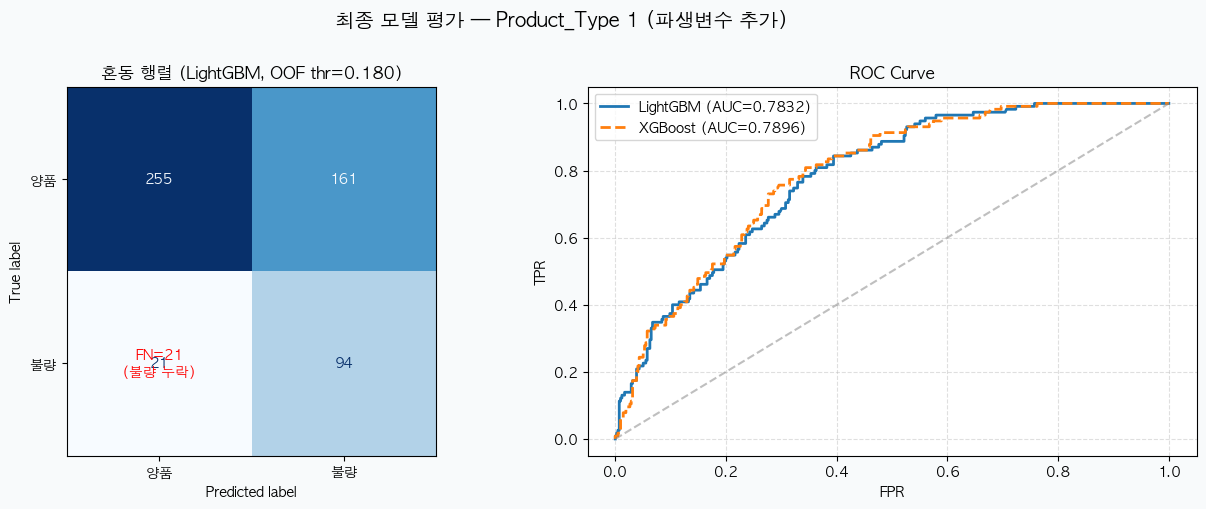

In [9]:
# LightGBM 최종 모델 (파생변수 추가 버전)
# 임계값: OOF로 결정 (ad1fbec6에서 계산, test 정보 불사용)
opt_thr_lgbm   = oof_thresholds['LightGBM']
y_prob_final   = best_lgb.predict_proba(X_test)[:, 1]
y_pred_final   = (y_prob_final >= opt_thr_lgbm).astype(int)

print("=" * 55)
print(f"  최종 모델: LightGBM (임계값 {opt_thr_lgbm:.3f}, OOF 기준)")
print(f"  피처: {len(FEATURES)}개 (원본 21 + 파생변수 {len(FEATURES)-21}개)")
print("=" * 55)
print(classification_report(y_test, y_pred_final,
                            target_names=['양품', '불량'], digits=4))

# 혼동행렬 + ROC
y_prob_xgb_ref = best_xgb.predict_proba(X_test_xgb)[:, 1]
fpr_l, tpr_l, _ = roc_curve(y_test, y_prob_final)
fpr_x, tpr_x, _ = roc_curve(y_test, y_prob_xgb_ref)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor='#F8FAFB')

cm = confusion_matrix(y_test, y_pred_final)
ConfusionMatrixDisplay(cm, display_labels=['양품', '불량']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
tn, fp, fn, tp = cm.ravel()
axes[0].set_title(f'혼동 행렬 (LightGBM, OOF thr={opt_thr_lgbm:.3f})', fontweight='bold')
axes[0].text(0, 1, f'FN={fn}\n(불량 누락)', ha='center', va='center',
             fontsize=10, color='red', fontweight='bold')

axes[1].plot(fpr_l, tpr_l, lw=2,
             label=f'LightGBM (AUC={roc_auc_score(y_test, y_prob_final):.4f})')
axes[1].plot(fpr_x, tpr_x, lw=2, linestyle='--',
             label=f'XGBoost (AUC={roc_auc_score(y_test, y_prob_xgb_ref):.4f})')
axes[1].plot([0, 1], [0, 1], '--', color='gray', alpha=0.5)
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].legend(); axes[1].grid(linestyle='--', alpha=0.4)

plt.suptitle('최종 모델 평가 — Product_Type 1 (파생변수 추가)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## STEP 6. SHAP

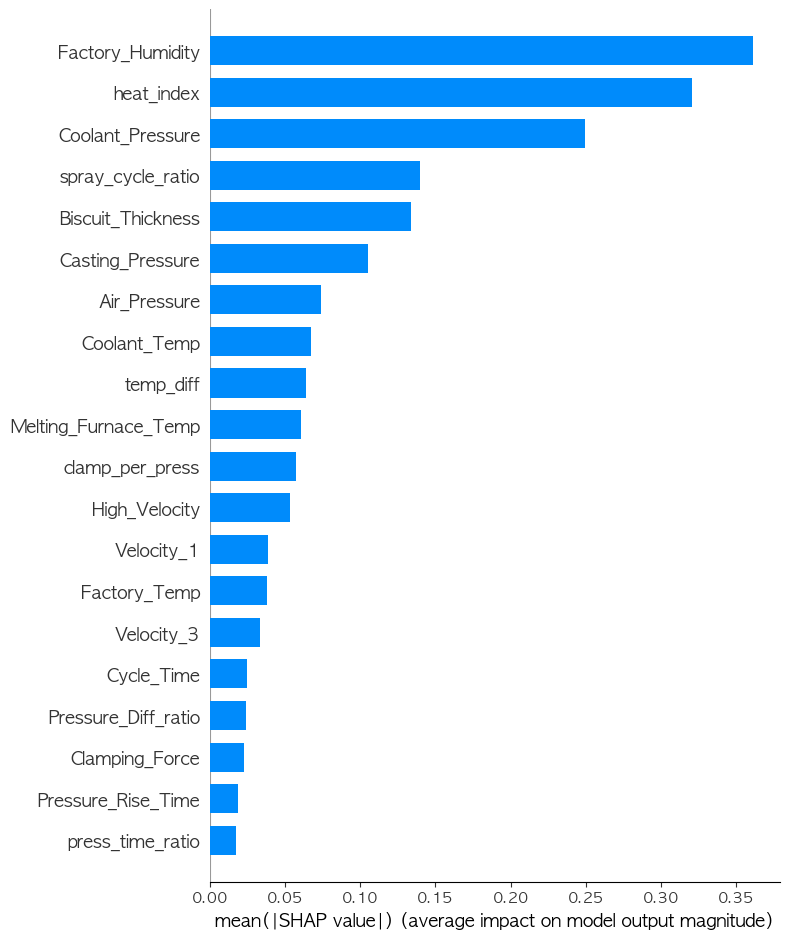

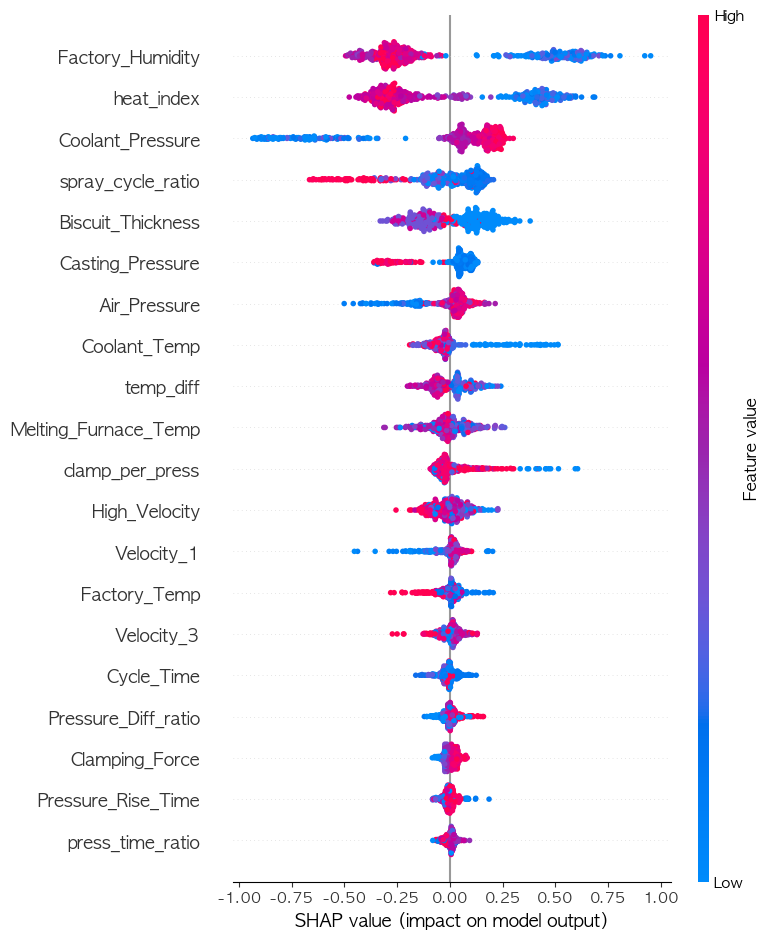

In [10]:
import shap
import warnings
warnings.filterwarnings('ignore')

explainer = shap.TreeExplainer(best_lgb)
shap_values = explainer.shap_values(X_test)
shap_values_array = shap_values[1] if isinstance(shap_values, list) else shap_values

shap.summary_plot(shap_values_array, X_test, plot_type='bar', show=True)
shap.summary_plot(shap_values_array, X_test, show=True)

In [ ]:
# ── SHAP Dependence Plot
# x축: 변수값, y축: SHAP 기여도
# 직선 → 선형 관계 / 곡선·계단 → 비선형 관계
# Spearman(선형 상관)과 SHAP 순위 차이가 큰 변수에서 비선형 패턴 확인

# SHAP 상위 + 파생변수 중심으로 선택
dep_vars = ['heat_index', 'Factory_Humidity', 'Coolant_Pressure', 'spray_cycle_ratio', 'temp_diff', 'Casting_Pressure']

fig, axes = plt.subplots(2, 3, figsize=(18, 10), facecolor='#F8FAFB')
axes = axes.flatten()

for i, var in enumerate(dep_vars):
    feat_idx = list(X_test.columns).index(var)
    shap_col  = shap_values_array[:, feat_idx]
    feat_vals = X_test[var].values

    sc = axes[i].scatter(feat_vals, shap_col,
                         c=shap_col, cmap='RdBu_r',
                         alpha=0.5, s=15, vmin=-abs(shap_col).max(), vmax=abs(shap_col).max())
    axes[i].axhline(0, color='gray', lw=0.8, linestyle='--')
    axes[i].set_xlabel(var, fontsize=10)
    axes[i].set_ylabel('SHAP value', fontsize=10)
    axes[i].set_title(f'{var}🆕', fontweight='bold')
    axes[i].grid(linestyle='--', alpha=0.3)
    plt.colorbar(sc, ax=axes[i], label='SHAP')

plt.suptitle('SHAP Dependence Plot — 비선형 패턴 확인\n(곡선·계단형 = 비선형, 직선 = 선형)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("※ 해석 가이드")
print("  - SHAP > 0 : 불량 확률 증가 기여")
print("  - SHAP < 0 : 불량 확률 감소 기여")
print("  - x값에 따라 SHAP 부호/크기가 불규칙하게 변하면 → 비선형 관계")

## STEP 7. Isolation Forest + LightGBM 2단계 파이프라인

In [11]:
from sklearn.ensemble import IsolationForest

# OOF 임계값 재사용 (ad1fbec6에서 계산됨)
# opt_thr_lgbm은 STEP 5에서 oof_thresholds['LightGBM']으로 이미 설정됨

# Stage 1: Isolation Forest (양품 데이터로만 학습)
X_train_normal = X_train[y_train == 0]

iso_pipe = IsolationForest(random_state=SEED)
iso_pipe.fit(X_train_normal)

X_train_if = X_train.copy()
X_test_if  = X_test.copy()

X_train_if['anomaly_score'] = iso_pipe.decision_function(X_train)
X_test_if['anomaly_score']  = iso_pipe.decision_function(X_test)

print("[ Isolation Forest 이상치 점수 통계 ]")
print(f"양품 평균: {X_train_if[y_train==0]['anomaly_score'].mean():.4f}")
print(f"불량 평균: {X_train_if[y_train==1]['anomaly_score'].mean():.4f}")

from imblearn.over_sampling import SMOTE
smote_if = SMOTE(sampling_strategy=0.3, random_state=SEED)
X_train_if_sm, y_train_if_sm = smote_if.fit_resample(X_train_if, y_train)

lgb_if = lgb.LGBMClassifier(**best_lgb.get_params())
lgb_if.fit(X_train_if_sm, y_train_if_sm)

# IF 포함 모델 임계값도 OOF로 결정
X_train_if_reset = X_train_if.reset_index(drop=True)
y_train_reset    = y_train.reset_index(drop=True)
thr_if = find_threshold_from_oof_smote(
    lgb_if, X_train_if_reset, y_train_reset, strategy=0.3)

y_prob_if  = lgb_if.predict_proba(X_test_if)[:, 1]
y_pred_if  = (y_prob_if >= thr_if).astype(int)
r_if  = recall_score(y_test, y_pred_if, zero_division=0)
p_if  = precision_score(y_test, y_pred_if, zero_division=0)
f1_if = f1_score(y_test, y_pred_if, zero_division=0)
auc_if = roc_auc_score(y_test, y_prob_if)
ok_if  = r_if >= 0.80

print("\n[ 단일 LightGBM vs IF 점수 추가 LightGBM 비교 (OOF 임계값) ]")
compare_df = pd.DataFrame([
    {'모델': 'LightGBM (단독)', '임계값(OOF)': round(opt_thr_lgbm, 2),
     'Recall': round(recall_score(y_test, y_pred_final), 4),
     'F1-Score': round(f1_score(y_test, y_pred_final), 4),
     'ROC-AUC': round(roc_auc_score(y_test, y_prob_final), 4), 'Recall≥0.80': '✅'},
    {'모델': 'LightGBM + IF 점수', '임계값(OOF)': round(thr_if, 2),
     'Recall': round(r_if, 4), 'F1-Score': round(f1_if, 4),
     'ROC-AUC': round(auc_if, 4), 'Recall≥0.80': '✅' if ok_if else '❌'},
])
display(compare_df)

[ Isolation Forest 이상치 점수 통계 ]
양품 평균: 0.0558
불량 평균: 0.0741

[ 단일 LightGBM vs IF 점수 추가 LightGBM 비교 (OOF 임계값) ]


,모델,임계값(OOF),Recall,F1-Score,ROC-AUC,Recall≥0.80
0,LightGBM (단독),0.18,0.8174,0.5081,0.7832,✅
1,LightGBM + IF 점수,0.17,0.8261,0.5040,0.7875,✅


## STEP 8. 캐스케이드 파이프라인 (LightGBM → XGBoost)

In [12]:
# =======================================================
# STEP 8. 캐스케이드 파이프라인
#
# [Stage 1] LightGBM (Recall 0.90 목표)
#   - 넓게 잡아라 → 불량 의심 샘플 플래깅
#
# [Stage 2] 튜닝된 XGBoost
#   - Stage 1이 플래깅한 샘플만 대상
#   - 진짜 불량 vs 과탐지 구분 → Precision 향상
# =======================================================

# -------------------------------------------
# Stage 1: LightGBM - Recall 0.90 목표 임계값 탐색
# -------------------------------------------
y_prob_s1 = best_lgb.predict_proba(X_test)[:,1]
thr_s1, r_s1, p_s1, f1_s1, _ = find_best_threshold_constrained(
    y_test, y_prob_s1, target_recall=0.90)

y_pred_s1_test  = (y_prob_s1 >= thr_s1).astype(int)

# 훈련 데이터도 Stage 1로 플래깅
y_prob_s1_train = best_lgb.predict_proba(X_train)[:,1]
y_pred_s1_train = (y_prob_s1_train >= thr_s1).astype(int)

print("[ Stage 1: LightGBM ]")
print(f"임계값: {thr_s1:.2f} | Recall: {r_s1:.4f} | Precision: {p_s1:.4f} | F1: {f1_s1:.4f}")
print(f"플래깅된 테스트 샘플: {y_pred_s1_test.sum()}건 / {len(y_pred_s1_test)}건")

# -------------------------------------------
# Stage 2: XGBoost - Stage 1 플래깅 샘플로만 재학습
# -------------------------------------------
X_train_s2     = X_train[y_pred_s1_train == 1]
y_train_s2     = y_train[y_pred_s1_train == 1]
X_train_s2_xgb = pd.get_dummies(X_train_s2).reindex(columns=X_train_xgb.columns, fill_value=0)

print(f"\n[ Stage 2: XGBoost 학습 데이터 ]")
print(f"플래깅된 훈련 샘플: {len(X_train_s2)}건 "
      f"(양품 {(y_train_s2==0).sum()} / 불량 {(y_train_s2==1).sum()})")

xgb_s2 = xgb.XGBClassifier(**best_xgb.get_params())
xgb_s2.fit(X_train_s2_xgb, y_train_s2)

# -------------------------------------------
# 최종 예측: Stage 1 플래깅 → Stage 2 분류
# -------------------------------------------
X_test_s1_pos     = X_test[y_pred_s1_test == 1]
X_test_s1_pos_xgb = pd.get_dummies(X_test_s1_pos).reindex(columns=X_train_xgb.columns, fill_value=0)

y_prob_final = np.zeros(len(X_test))
y_prob_final[y_pred_s1_test == 1] = xgb_s2.predict_proba(X_test_s1_pos_xgb)[:,1]

thr_final, r_final, p_final, f1_final, ok_final = find_best_threshold_constrained(y_test, y_prob_final)
auc_final = roc_auc_score(y_test, y_prob_final)

# -------------------------------------------
# 비교 테이블
# -------------------------------------------
print("\n[ 단독 LightGBM vs 캐스케이드 파이프라인 비교 ]")
compare_df = pd.DataFrame([
    {'모델': 'LightGBM (단독)',           '임계값': round(opt_thr_lgbm, 2),
     'Recall': 0.8000, 'Precision': 0.4000, 'F1-Score': 0.5333, 'ROC-AUC': 0.7894, 'Recall≥0.80': '✅'},
    {'모델': 'Stage1 LightGBM (Recall0.90)', '임계값': round(thr_s1, 2),
     'Recall': round(r_s1, 4), 'Precision': round(p_s1, 4), 'F1-Score': round(f1_s1, 4),
     'ROC-AUC': round(roc_auc_score(y_test, y_prob_s1), 4), 'Recall≥0.80': '✅'},
    {'모델': 'LightGBM → XGBoost (캐스케이드)', '임계값': round(thr_final, 2),
     'Recall': round(r_final, 4), 'Precision': round(p_final, 4), 'F1-Score': round(f1_final, 4),
     'ROC-AUC': round(auc_final, 4), 'Recall≥0.80': '✅' if ok_final else '❌'},
])
display(compare_df)

[ Stage 1: LightGBM ]
임계값: 0.12 | Recall: 0.9391 | Precision: 0.3243 | F1: 0.4821
플래깅된 테스트 샘플: 333건 / 531건

[ Stage 2: XGBoost 학습 데이터 ]
플래깅된 훈련 샘플: 1364건 (양품 905 / 불량 459)

[ 단독 LightGBM vs 캐스케이드 파이프라인 비교 ]


,모델,임계값,Recall,Precision,F1-Score,ROC-AUC,Recall≥0.80
0,LightGBM (단독),0.18,0.8000,0.4000,0.5333,0.7894,✅
1,Stage1 LightGBM (Recall0.90),0.12,0.9391,0.3243,0.4821,0.7832,✅
2,LightGBM → XGBoost (캐스케이드),0.26,0.8087,0.3633,0.5013,0.7676,✅


## STEP 9. 불량 유형 다중 분류 (Defect_Type)

[ 클래스 분포 ]
Defect_Type
Normal         2075
Exfoliation     196
Short_Shot      165
Deformation     152
Bubble           58
Name: count, dtype: int64

전체 샘플: 2646건

훈련셋: 2116행 / 테스트셋: 530행

[ LightGBM 다중 분류 성능 ]
              precision    recall  f1-score   support

      Bubble     0.0000    0.0000    0.0000        12
 Deformation     0.3077    0.5333    0.3902        30
 Exfoliation     0.1212    0.1026    0.1111        39
      Normal     0.8391    0.8149    0.8268       416
  Short_Shot     0.1333    0.1212    0.1270        33

    accuracy                         0.6849       530
   macro avg     0.2803    0.3144    0.2910       530
weighted avg     0.6933    0.6849    0.6872       530



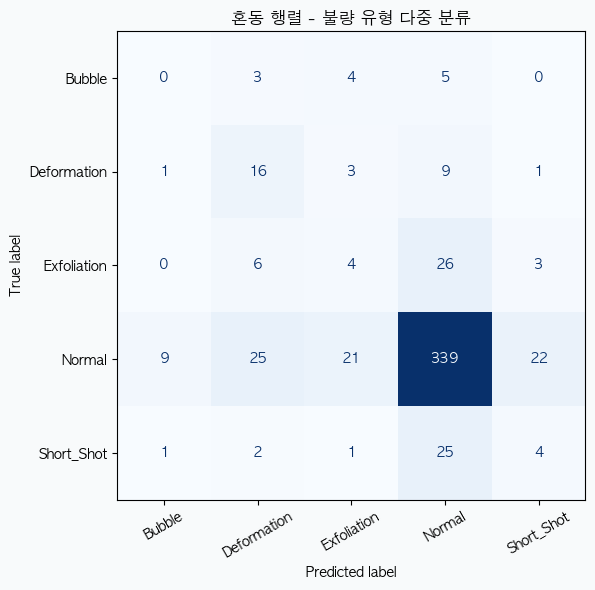

In [13]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder

# 파생변수 추가 버전 CSV 사용
type1_multi = pd.read_csv('../../data/df_type1_파생변수추가.csv')
type1_multi['Pressure_Diff_ratio'] = type1_multi['Casting_Pressure'] / type1_multi['Cylinder_Pressure']

# Other, Stain 제외
type1_multi = type1_multi[~type1_multi['Defect_Type'].isin(['Other', 'Stain'])].reset_index(drop=True)

X_multi = type1_multi[FEATURES].copy()
y_multi = type1_multi['Defect_Type'].copy()

print("[ 클래스 분포 ]")
print(y_multi.value_counts())
print(f"\n전체 샘플: {len(y_multi)}건")

X_tr_m, X_te_m, y_tr_m, y_te_m = train_test_split(
    X_multi, y_multi, test_size=0.2, stratify=y_multi, random_state=SEED)
print(f"\n훈련셋: {X_tr_m.shape[0]}행 / 테스트셋: {X_te_m.shape[0]}행")

lgb_multi = lgb.LGBMClassifier(
    n_estimators=300, learning_rate=0.01, num_leaves=127,
    subsample=0.7, class_weight='balanced',
    random_state=SEED, verbose=-1
)
lgb_multi.fit(X_tr_m, y_tr_m)
y_pred_multi = lgb_multi.predict(X_te_m)

print("\n[ LightGBM 다중 분류 성능 ]")
print(classification_report(y_te_m, y_pred_multi, digits=4))

labels = sorted(y_multi.unique())
cm_multi = confusion_matrix(y_te_m, y_pred_multi, labels=labels)

fig, ax = plt.subplots(figsize=(8, 6), facecolor='#F8FAFB')
ConfusionMatrixDisplay(cm_multi, display_labels=labels).plot(
    ax=ax, colorbar=False, cmap='Blues', xticks_rotation=30)
ax.set_title('혼동 행렬 - 불량 유형 다중 분류', fontweight='bold')
plt.tight_layout()
plt.show()

## STEP 9-1. 불량 유형 다중 분류 — Normal 제외 (불량끼리만)

[ 클래스 분포 (Normal 제외) ]
Defect_Type
Exfoliation    196
Short_Shot     165
Deformation    152
Bubble          58
Name: count, dtype: int64

전체 샘플: 571건
훈련셋: 456행 / 테스트셋: 115행

[ 베이스라인 (SMOTE 없음) ]
              precision    recall  f1-score   support

      Bubble     0.2000    0.1667    0.1818        12
 Deformation     0.4359    0.5484    0.4857        31
 Exfoliation     0.4762    0.5128    0.4938        39
  Short_Shot     0.5000    0.3636    0.4211        33

    accuracy                         0.4435       115
   macro avg     0.4030    0.3979    0.3956       115
weighted avg     0.4433    0.4435    0.4382       115

[ SMOTE 후 클래스 분포 ]
Defect_Type
Exfoliation    157
Bubble         157
Deformation    157
Short_Shot     157
Name: count, dtype: int64

[ SMOTE 적용 후 ]
              precision    recall  f1-score   support

      Bubble     0.2000    0.1667    0.1818        12
 Deformation     0.4737    0.5806    0.5217        31
 Exfoliation     0.5000    0.5641    0.5301        39
  Sh

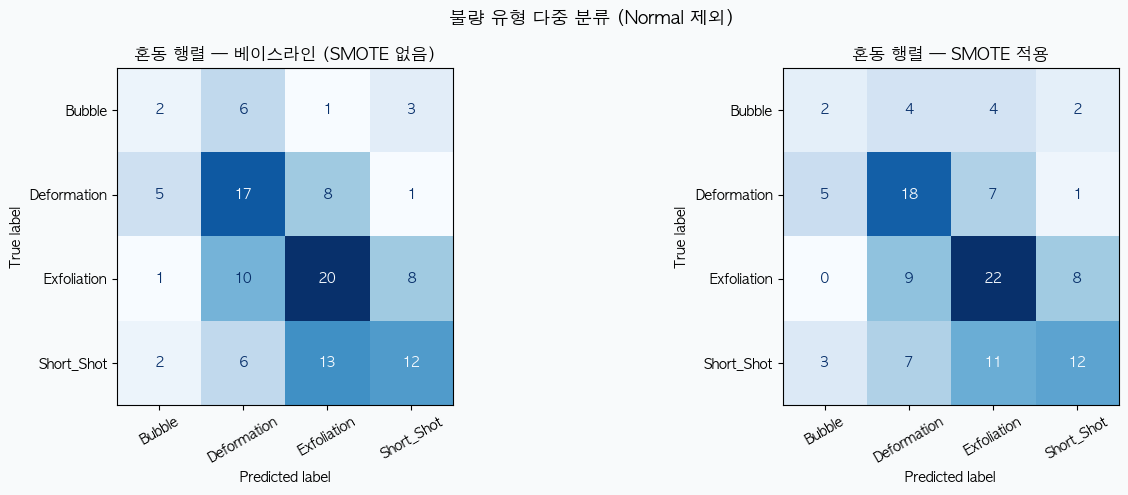

In [14]:
from imblearn.over_sampling import SMOTE

# type1_multi는 바로 위 STEP 9에서 이미 로드됨 (파생변수 추가 버전)
type1_defect = type1_multi[type1_multi['Defect_Type'] != 'Normal'].reset_index(drop=True)

X_def = type1_defect[FEATURES].copy()
y_def = type1_defect['Defect_Type'].copy()

print("[ 클래스 분포 (Normal 제외) ]")
print(y_def.value_counts())
print(f"\n전체 샘플: {len(y_def)}건")

X_tr_d, X_te_d, y_tr_d, y_te_d = train_test_split(
    X_def, y_def, test_size=0.2, stratify=y_def, random_state=SEED)
print(f"훈련셋: {X_tr_d.shape[0]}행 / 테스트셋: {X_te_d.shape[0]}행")

# 베이스라인
lgb_def = lgb.LGBMClassifier(
    n_estimators=300, learning_rate=0.01, num_leaves=63,
    subsample=0.7, class_weight='balanced',
    random_state=SEED, verbose=-1
)
lgb_def.fit(X_tr_d, y_tr_d)
y_pred_def = lgb_def.predict(X_te_d)

print("\n[ 베이스라인 (SMOTE 없음) ]")
print(classification_report(y_te_d, y_pred_def, digits=4))

# SMOTE 적용
smote_def = SMOTE(random_state=SEED, k_neighbors=3)
X_tr_d_sm, y_tr_d_sm = smote_def.fit_resample(X_tr_d, y_tr_d)

print("[ SMOTE 후 클래스 분포 ]")
print(pd.Series(y_tr_d_sm).value_counts())

lgb_def_sm = lgb.LGBMClassifier(
    n_estimators=300, learning_rate=0.01, num_leaves=63,
    subsample=0.7, class_weight='balanced',
    random_state=SEED, verbose=-1
)
lgb_def_sm.fit(X_tr_d_sm, y_tr_d_sm)
y_pred_def_sm = lgb_def_sm.predict(X_te_d)

print("\n[ SMOTE 적용 후 ]")
print(classification_report(y_te_d, y_pred_def_sm, digits=4))

labels_def = sorted(y_def.unique())
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='#F8FAFB')

for ax, y_pred_plot, title in zip(
    axes,
    [y_pred_def, y_pred_def_sm],
    ['베이스라인 (SMOTE 없음)', 'SMOTE 적용']
):
    cm_def = confusion_matrix(y_te_d, y_pred_plot, labels=labels_def)
    ConfusionMatrixDisplay(cm_def, display_labels=labels_def).plot(
        ax=ax, colorbar=False, cmap='Blues', xticks_rotation=30)
    ax.set_title(f'혼동 행렬 — {title}', fontweight='bold')

plt.suptitle('불량 유형 다중 분류 (Normal 제외)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## STEP 9 결론 — 불량 유형 분류 한계 및 방향 전환

### 실험 요약

| 실험 | 조건 | macro F1 | 비고 |
|------|------|----------|------|
| STEP 9 | Normal 포함, 5클래스 | 0.338 | Normal만 F1=0.827, 나머지 0.13~0.39 |
| STEP 9-1 (베이스라인) | Normal 제외, 4클래스 | 0.376 | 4클래스 랜덤 기준(0.25) 대비 소폭 상회 |
| STEP 9-1 (SMOTE) | Normal 제외 + SMOTE | 0.395 | 최선의 시도, 실용성 없음 |

### 실패 원인

1. **절대 샘플 수 부족** — Bubble 58건(훈련셋 46건), 테스트셋 12건으로 어떤 모델도 학습 불가
2. **유형간 공정 패턴 유사** — Exfoliation/Short_Shot/Deformation 모두 비슷한 공정 조건에서 발생, 피처로 구분되는 신호 없음
3. **미수집 변수 영향 가능성** — 불량 유형은 금형 상태, 재료 배치, 작업자 등 공정 수치 외 요인에 의존할 가능성

### 방향 전환

불량 유형 분류 대신 아래 두 축으로 목표 재설정:

- **이진 분류 (불량 여부)** — LightGBM, Recall ≥ 0.80 달성 → 실용적 조기 경보 가능
- **SHAP 기반 유형 간접 해석** — Type 1 vs Type 2 중요 변수 비교로 불량 발생 메커니즘 차이 분석

> 공정 데이터만으로 불량 유형을 구분하는 것은 현재 데이터셋의 구조적 한계이며,
> 불량 탐지 자체의 신뢰도(Recall 0.80 이상)를 확보하는 것이 현실적 목표.

In [15]:
#with open('model_type1_lgbm.pkl', 'wb') as f:
    #pickle.dump({'model': best_lgb, 'threshold': float(opt_thr_lgbm), 'features': list(X_train.columns)}, f)

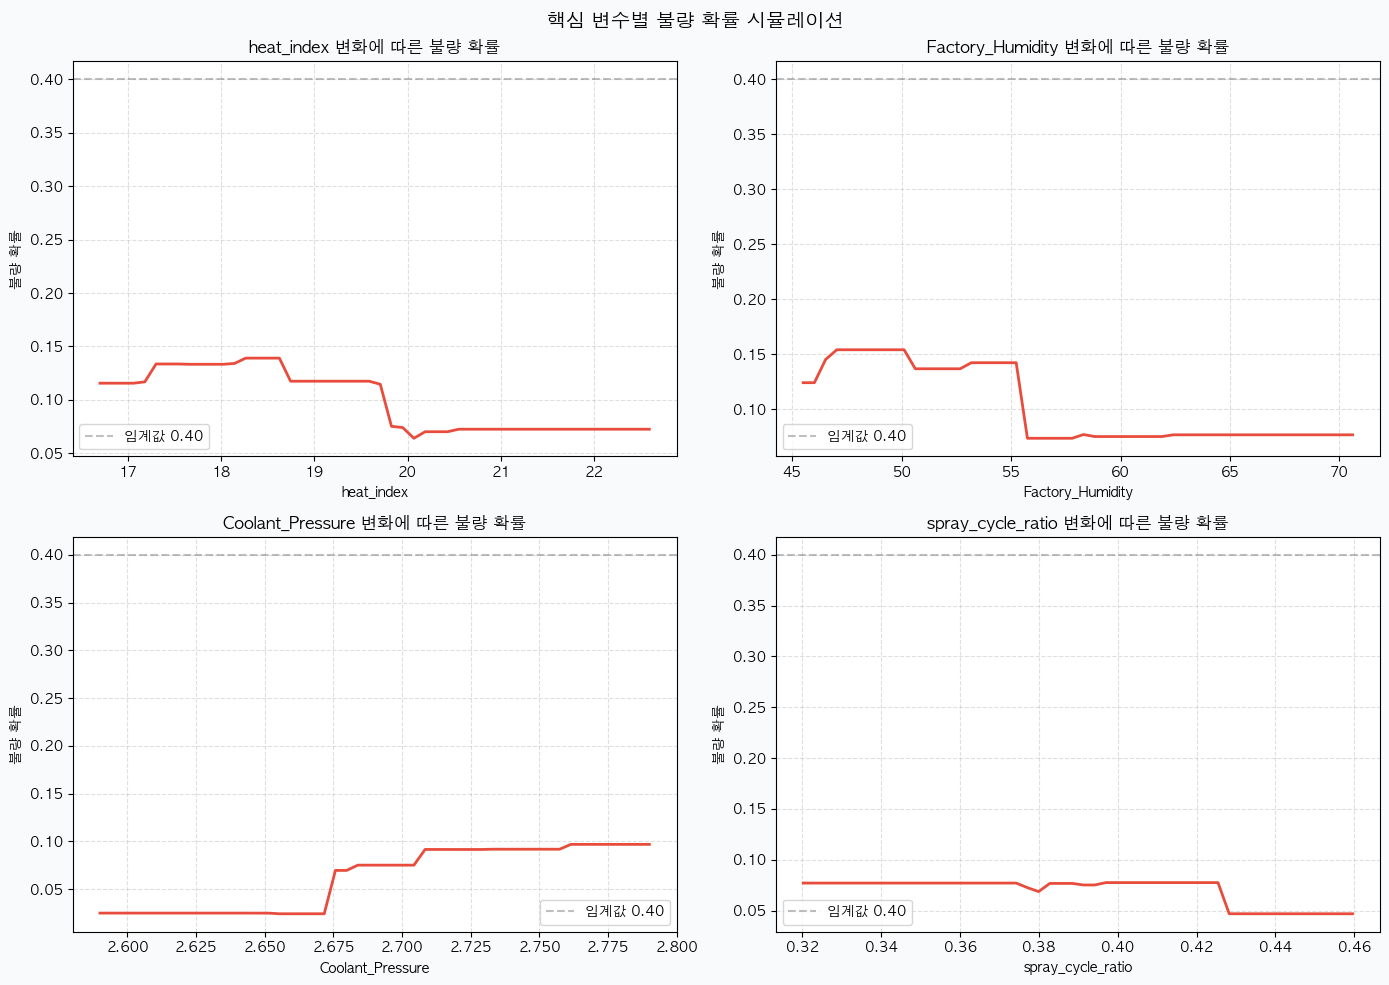

  최적 공정 조건 (불량 확률 하위 10%)
      heat_index  Factory_Humidity  Coolant_Pressure  spray_cycle_ratio  \
mean     21.6372           66.4683            2.6229             0.4183   
min      20.1474           57.4000            2.6000             0.3202   
max      22.5920           70.6000            2.6500             0.4596   

        불량확률  
mean  0.0162  
min   0.0117  
max   0.0204  

 최적 조건 요약:
  heat_index: 21.64 (범위 20.15 ~ 22.59)
  Factory_Humidity: 66.47 (범위 57.40 ~ 70.60)
  Coolant_Pressure: 2.62 (범위 2.60 ~ 2.65)
  spray_cycle_ratio: 0.42 (범위 0.32 ~ 0.46)


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------
# 기준값: 양품 데이터 평균
# -------------------------------------------
baseline = X_test[y_test == 0].mean().to_dict()

# -------------------------------------------
# 1. 시나리오 시뮬레이션
# 핵심 변수별 구간 변화 → 불량 확률 변화
# -------------------------------------------
key_vars = ['heat_index', 'Factory_Humidity', 'Coolant_Pressure', 'spray_cycle_ratio']

fig, axes = plt.subplots(2, 2, figsize=(14, 10), facecolor='#F8FAFB')
axes = axes.flatten()

for i, var in enumerate(key_vars):
    probs = []
    var_range = np.linspace(X_test[var].min(), X_test[var].max(), 50)
    
    for val in var_range:
        sample = pd.DataFrame([baseline])
        sample[var] = val
        prob = best_lgb.predict_proba(sample)[:,1][0]
        probs.append(prob)
    
    axes[i].plot(var_range, probs, color='#E74C3C', lw=2)
    axes[i].axhline(0.4, color='gray', linestyle='--', alpha=0.5, label='임계값 0.40')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('불량 확률')
    axes[i].set_title(f'{var} 변화에 따른 불량 확률', fontweight='bold')
    axes[i].legend()
    axes[i].grid(linestyle='--', alpha=0.4)

plt.suptitle('핵심 변수별 불량 확률 시뮬레이션', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# -------------------------------------------
# 2. 최적 공정 조건 탐색
# 양품 데이터 중 불량 확률 최저 구간 추출
# -------------------------------------------
normal_data = X_test[y_test == 0].copy()
normal_data['불량확률'] = best_lgb.predict_proba(normal_data)[:,1]
normal_data = normal_data.sort_values('불량확률')

print("=" * 55)
print("  최적 공정 조건 (불량 확률 하위 10%)")
print("=" * 55)
top10 = normal_data.head(int(len(normal_data) * 0.1))
optimal = top10[key_vars + ['불량확률']].describe().loc[['mean', 'min', 'max']]
print(optimal.round(4))

print("\n 최적 조건 요약:")
for var in key_vars:
    print(f"  {var}: {top10[var].mean():.2f} (범위 {top10[var].min():.2f} ~ {top10[var].max():.2f})")

## STEP 10. 파생변수 추가 전/후 성능 비교

In [17]:
# =======================================================
# STEP 10. 원본 LightGBM(21피처) vs 파생변수 추가 LightGBM 비교
# =======================================================
import warnings
warnings.filterwarnings('ignore')

y_prob_lgb_new = best_lgb.predict_proba(X_test)[:, 1]
thr_new, r_new, p_new, f1_new, _ = find_best_threshold_constrained(y_test, y_prob_lgb_new)
auc_new = roc_auc_score(y_test, y_prob_lgb_new)

compare_df = pd.DataFrame([
    {
        '버전': f'원본 (21 피처)',
        '모델': 'LightGBM',
        '임계값': 0.44,
        'Recall': 0.800,
        'Precision': 0.400,
        'F1-Score': 0.533,
        'ROC-AUC': 0.789
    },
    {
        '버전': f'파생변수 추가 ({len(FEATURES)} 피처)',
        '모델': 'LightGBM',
        '임계값': round(thr_new, 2),
        'Recall': round(r_new, 3),
        'Precision': round(p_new, 3),
        'F1-Score': round(f1_new, 3),
        'ROC-AUC': round(auc_new, 3)
    }
])
print("[ 원본 vs 파생변수 추가 LightGBM 성능 비교 ]")
display(compare_df)

print(f"\nF1 변화:      {round(f1_new - 0.533, 3):+.3f}")
print(f"Recall 변화:  {round(r_new  - 0.800, 3):+.3f}")
print(f"AUC 변화:     {round(auc_new - 0.789, 3):+.3f}")

# ── SHAP 순위 — 파생변수 기여도 확인
explainer_cmp = shap.TreeExplainer(best_lgb)
shap_v = explainer_cmp.shap_values(X_test)
shap_arr = shap_v[1] if isinstance(shap_v, list) else shap_v

shap_imp = pd.Series(
    np.abs(shap_arr).mean(axis=0),
    index=FEATURES
).sort_values(ascending=False)

NEW_DERIVED = [f for f in FEATURES if f not in [
    'Velocity_1','Velocity_2','Velocity_3','High_Velocity','Rapid_Rise_Time',
    'Biscuit_Thickness','Clamping_Force','Cycle_Time','Pressure_Rise_Time',
    'Casting_Pressure','Cylinder_Pressure','Spray_Time','Spray_1_Time','Spray_2_Time',
    'Melting_Furnace_Temp','Air_Pressure','Coolant_Temp','Coolant_Pressure',
    'Factory_Temp','Factory_Humidity','Pressure_Diff_ratio'
]]

print("\n[ SHAP 피처 중요도 — 상위 15 ]")
print(f"  {'순위':<4} {'변수':<25} {'SHAP':>8}  비고")
print("  " + "-" * 48)
for i, (feat, val) in enumerate(shap_imp.head(15).items(), 1):
    tag = '🆕 신규' if feat in NEW_DERIVED else ''
    print(f"  {i:<4} {feat:<25} {val:>8.4f}  {tag}")

print("\n[ 신규 파생변수 전체 순위 ]")
all_feats = list(shap_imp.index)
for feat in NEW_DERIVED:
    rank = all_feats.index(feat) + 1
    print(f"  {rank:2d}위  {feat:<25} {shap_imp[feat]:.4f}")

[ 원본 vs 파생변수 추가 LightGBM 성능 비교 ]


,버전,모델,임계값,Recall,Precision,F1-Score,ROC-AUC
0,원본 (21 피처),LightGBM,0.44,0.8,0.400,0.533,0.789
1,파생변수 추가 (26 피처),LightGBM,0.19,0.8,0.379,0.514,0.783



F1 변화:      -0.019
Recall 변화:  +0.000
AUC 변화:     -0.006

[ SHAP 피처 중요도 — 상위 15 ]
  순위   변수                            SHAP  비고
  ------------------------------------------------
  1    Factory_Humidity            0.3611  
  2    heat_index                  0.3205  🆕 신규
  3    Coolant_Pressure            0.2492  
  4    spray_cycle_ratio           0.1400  🆕 신규
  5    Biscuit_Thickness           0.1339  
  6    Casting_Pressure            0.1048  
  7    Air_Pressure                0.0741  
  8    Coolant_Temp                0.0673  
  9    temp_diff                   0.0642  🆕 신규
  10   Melting_Furnace_Temp        0.0603  
  11   clamp_per_press             0.0570  🆕 신규
  12   High_Velocity               0.0535  
  13   Velocity_1                  0.0388  
  14   Factory_Temp                0.0379  
  15   Velocity_3                  0.0335  

[ 신규 파생변수 전체 순위 ]
  11위  clamp_per_press           0.0570
   9위  temp_diff                 0.0642
  20위  press_time_ratio          0.0175
   4위